**Ch121a | Module 3: Periodic DFT**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppt-2/Ch121a-DFT/blob/main/Module3_Periodic-DFT/notebooks/04a_example_calculations.ipynb)

# Notebook 4a: Basic Example Calculations: Si DOS & Band Gap

---

## Learning Objectives

- SCF → Band gap (Si)
- Plotting the Density of States (DOS) and band structure
- PBE band-gap underestimation problem

## 1. Si Band gap

```Kept in ../tmp/Si_dos/vasp/```

Silicon has a diamond-cubic structure (Fd-3m, 8 atoms/cell) and an indirect band gap of ~1.17 eV (experimental). PBE underestimates this to ~0.6 eV.

### Workflow: SCF → Band structure

The DOS calculation requires two steps:
1. **SCF**: converge the charge density and save WAVECAR + CHGCAR
2. **Non-SCF DOS**: read the charge density (ICHARG=11), use tetrahedron smearing (ISMEAR=-5), and increase NEDOS

#### Easy POSCARs: 
```
Si bulk
5.430      # Used this scaling factor, to scale the box vectors itself
0.5 0.5 0.0 # Notice the fractions of box vectors - primitive cell 
0.0 0.5 0.5
0.5 0.0 0.5
Si
2
cart         # Since box vector is itself scaled
0.00 0.00 0.00
0.25 0.25 0.25
```
#### Full POSCARs: 
Si bulk diamond cubic (also kept in ../tmp/Si_dos/vasp/)
1.0
   2.734950    2.734950    0.000000
   0.000000    2.734950    2.734950
   2.734950    0.000000    2.734950
Si
2
Direct
  0.000000  0.000000  0.000000
  0.250000  0.250000  0.250000

### Step 1: INCAR_scf


```
# INCAR — Step 1: Self-consistent field (SCF) for Si
SYSTEM  = Si bulk PBE
ISTART  = 0          # start from scratch
ICHARG  = 2          # superposition of atomic charges
ENCUT   = 400        # plane-wave cutoff (eV)
PREC    = Accurate
EDIFF   = 1E-5       # energy convergence (eV) **Change to 1E-6 for homework**
NSW     = 0          # no ionic relaxation
ISMEAR  = 0          # Gaussian smearing
SIGMA   = 0.05       # smearing width (eV)
ALGO    = Fast
LWAVE   = .TRUE.     # write WAVECAR for DOS step
LCHARG  = .TRUE.     # write CHGCAR
```

### Step 2a: INCAR_DOS
Copy CHGCAR from previous step to DOS directory.

```
# INCAR — Step 2: DOS calculation for Si
SYSTEM  = Si bulk PBE DOS
ISTART  = 1          # read WAVECAR from SCF step
ICHARG  = 11         # non-self-consistent, read CHGCAR
ENCUT   = 400
PREC    = Accurate
EDIFF   = 1E-5       # **Change to 1E-6 for homework**
NSW     = 0
IBRION  = -1
ISMEAR  = -5         # tetrahedron method (best for DOS)
SIGMA   = 0.05
NEDOS   = 2000       # number of DOS grid points
LORBIT  = 11         # projected (lm-resolved) DOS
EMIN    = -10.0      # DOS energy range min (eV)
EMAX    =  10.0      # DOS energy range max (eV)
LWAVE   = .FALSE.
LCHARG  = .FALSE.
```
### Step b: INCAR_band



Copy CHGCAR from previous step to DOS directory.
**Key tags**: `NEDOS` sets the number of energy grid points (2000 gives smooth curves). `EMIN`/`EMAX` restrict the energy window. `LORBIT=11` writes atom- and lm-resolved PDOS to DOSCAR.

5.54777393


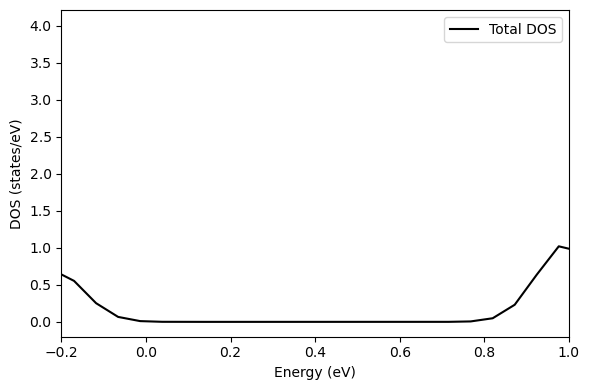

In [26]:
from ase.dft.dos import DOS
from ase.io import read
import matplotlib.pyplot as plt

# Read atoms and calculator (VASP)
atoms = read("../tmp/Si_dos/vasp/test/dos2/vasprun.xml")  # or read("OUTCAR")

# Build DOS object
dos = DOS(atoms.calc, width=0.1)  # Gaussian broadening

energies = dos.get_energies()     # Energy grid
total_dos = dos.get_dos()         # Total DOS
fermi = atoms.calc.get_fermi_level()
print (fermi)
# Plot
plt.figure(figsize=(6,4))
plt.plot(energies, total_dos, label="Total DOS", color="black")
plt.xlabel("Energy (eV)")
plt.xlim(-0.2, 1)
plt.ylabel("DOS (states/eV)")
plt.legend()
plt.tight_layout()
plt.show()


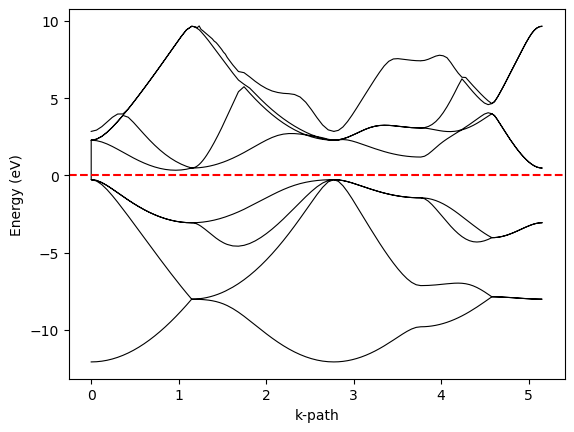

In [21]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("../tmp/Si_dos/vasp/test/band/BAND.dat")
k = data[:,0]
E = data[:,1:]

plt.plot(k, E, 'k-', linewidth=0.8)
plt.axhline(0, color='r', linestyle='--')  # Fermi level
plt.xlabel("k-path")
plt.ylabel("Energy (eV)")
#plt.ylim(-0.5,1)
plt.show()


## Homework
1. A-I: Calculate the ~HOMO-LUMO gap~ band gap of pentacene, this time, with its crystal structure, with PBE functional in periodic DFT. Comment whether a more accurate functional is important or the molecular crystallanity. In INCAR, also use IVDW = 12 tag in your INCAR files to include vdW corrections.
2. J-R: Calculate the surface energies of 100, 110 and 111 Li surfaces and comment on the reactivity of these surfaces.
3. S-Z: Molybdenum disulfide exists in two different structures, rhombohedral (3R) and hexagonal (2H). Compute band gap for both, with PBE. In INCAR, also use IVDW = 12 tag in your INCAR files to include vdW corrections.

## Further Reading

- Hybertsen & Louie, *Phys. Rev. B* **34**, 5390 (1986) — GW for band gaps
- Anisimov et al., *Phys. Rev. B* **44**, 943 (1991) — original LDA+U
- [VASP Wiki: DOS](https://www.vasp.at/wiki/Fcc_Ni_DOS)
- [VASP Wiki: Band structure](https://www.vasp.at/tutorials/latest/bulk/part1/#bulk-e03)
- [vaspkit Band Structure tutorial](https://vaspkit.com/tutorials.html#band-structure)

---
*Ch121a | Caltech | Module 3 — Notebook 4a of 6*